## Imports

Here we call the components for constraints, penalty aggregation, AEP, and other problem-specific modules.

In [2]:
import openmdao.api as om
import numpy as np
from pathlib import Path
import os
import sys
if ".." not in sys.path:
    sys.path.insert(0, "..")


"""import statements"""
from simplerecorder import SimpleRecorder
from mysite import get_setup_params
from aep import AEPCompStochastic, AEPComp
from constraints import SpacingConstraintComp, BoundaryConstraintComp
from aggregator import ConstraintAggregator
from penalty import PenaltyObjectiveComp, FinalRMSViol
from simpleplot import LayoutVisualizer

from Drivers import NCG, SGD

Loaded: default.csv (1 turbines)
Boundary: 0m x 0m


/Users/brunoboer/Documents/Software/PyWake_new/py_wake/deficit_models/gaussian.py:124: UserWarning: The BastankhahGaussian model is not representative of the setup used in the literature. For this, use py_wake.literature.gaussian_models.Bastankhah_PorteAgel_2014 instead
  DeprecatedModel.__init__(self, 'py_wake.literature.gaussian_models.Bastankhah_PorteAgel_2014')


In [3]:
def build_problem(K=50, csv_filename="default.csv", seed=1, driver=0):
    params = get_setup_params(csv_filename)

    site = params['site']
    turbine = params['turbine']
    wfm = params['wfm']
    x_init = params['x_init']
    y_init = params['y_init']
    boundary_vertices = params['boundary_vertices']
    min_spacing_d = params['min_spacing_d']
    n_turbines = params['n_turbines']
    D = params['diameter']

    min_spacing_m = min_spacing_d * D

    try:
        aep0 = float(wfm(x_init, y_init).aep().sum())
        print(f"Initial AEP: {aep0:.3f} GWh")
    except Exception as e:
        print(f"Initial AEP error: {e}")
        aep0 = None

    # Map integers/booleans to driver classes
    if isinstance(driver, bool):
        driver = int(driver)
    driver_map = {0: SGD, 1: NCG}
    try:
        DriverClass = driver_map[driver]
    except KeyError:
        raise ValueError("driver must be 0/1 or False/True (0->SGD, 1->NCG)")

    prob = om.Problem()
    m = prob.model

    driver_folder_name = DriverClass.__name__.lower()
    BASE_DIR = Path.cwd().parents[0]
    RESULTS_DIR = BASE_DIR / "Results" / driver_folder_name
    RESULTS_DIR.mkdir(exist_ok=True, parents=True)

    log_path = RESULTS_DIR / f"WESL_{n_turbines}wt_seed_{seed}.csv"


    recorder = SimpleRecorder(
        prob,
        out_path=log_path,
        x_name='x',
        y_name='y',
        aep_name='aep_comp_deterministic.aep',
        obj_name='objective',
        iter_name='opt_iter',
        viol_name='rms_viol'
    )
    recorder.start()

    indeps = m.add_subsystem('indeps', om.IndepVarComp(), promotes=['*'])
    indeps.add_output('x', val=x_init, units='m')
    indeps.add_output('y', val=y_init, units='m')
    indeps.add_output('opt_iter', val=0.0)

    aep_comp = AEPCompStochastic(
        wake_model=wfm,
        site=site,
        wt_x=x_init,
        wt_y=y_init,
        aep_ref=1.0,
        recorder=None,
        n_cpu=1,
        K=K,
    )

    m.add_subsystem(
        'aep_comp_deterministic',
        AEPComp(
            wake_model=wfm,
            wt_x=x_init,
            wt_y=y_init,
            aep_ref=1.0,
            n_cpu=1,
        ),
        promotes_inputs=['x', 'y']
    )

    m.add_subsystem(
        'aep_comp',
        aep_comp,
        promotes_inputs=['x', 'y'],
        promotes_outputs=['aep'],
    )

    spacing_comp = SpacingConstraintComp(
        n_turbines=n_turbines,
        min_spacing=min_spacing_m,
        eps=1e-12,
    )
    m.add_subsystem(
        'spacing_comp',
        spacing_comp,
        promotes_inputs=['x', 'y'],
        promotes_outputs=['spacing_cons'],
    )

    boundary_comp = BoundaryConstraintComp(
        boundary_vertices=boundary_vertices,
        n_turbines=n_turbines,
    )
    m.add_subsystem(
        'boundary_comp',
        boundary_comp,
        promotes_inputs=['x', 'y'],
        promotes_outputs=['boundary_cons'],
    )

    agg_comp = ConstraintAggregator(n_turbines=n_turbines)
    m.add_subsystem(
        'constraint_agg',
        agg_comp,
        promotes_inputs=['spacing_cons', 'boundary_cons'],
        promotes_outputs=['g_vector'],
    )

    penalty_comp = PenaltyObjectiveComp(n_constraints=agg_comp.m_total)
    m.add_subsystem(
        'penalty_comp',
        penalty_comp,
        promotes_inputs=['aep', 'g_vector'],
        promotes_outputs=['objective', 'penalty'],
    )

    nc = agg_comp.m_total
    m.add_subsystem(
        'rms_viol',
        FinalRMSViol(nconstraints=nc),
        promotes_outputs=['rms_viol']
    )
    m.connect('g_vector', 'rms_viol.g_vector')

    prob.driver = DriverClass(maxiter=10)
    prob.driver.options['learning_rate'] = params['diameter'] / 5.0
    prob.driver.options['gamma_min'] = 0.2 * (params['diameter'] / 5.0)
    prob.driver.options['lower'] = 1e-6
    prob.driver.options['upper'] = 1e-1
    prob.driver.options['tol'] = 1e-6
    prob.driver.options['disp'] = True
    prob.driver.recorder = recorder #(activate to generate csv files)

    m.add_design_var(
        'x',
        lower=boundary_vertices[:, 0].min(),
        upper=boundary_vertices[:, 0].max()
    )
    m.add_design_var(
        'y',
        lower=boundary_vertices[:, 1].min(),
        upper=boundary_vertices[:, 1].max()
    )

    m.add_objective('aep', scaler=-1.0)
    m.add_constraint('penalty', lower=0.0, scaler=1.0)

    return prob, recorder, log_path

In [4]:
def main(csv_filename="default.csv", K=50, seed=1, driver=0):
    csv_filename = f"100turb_3600m_kdt_{seed}.csv"

    prob, recorder, log_path = build_problem(
        K=K,
        csv_filename=csv_filename,
        seed=seed,
        driver=driver
    )

    prob.setup()
    prob.run_driver()

    return prob, recorder, log_path

## Run Problem


Here we initialize the problem with key parameters:
- **K**: number of samples
- **seed**: random seed for reproducibility
- **driver**: optimizer selection — `0` for SGD, `1` for NCG

A `SimpleRecorder` will be called when `prob.driver.recorder = recorder` is uncommented,
storing the optimization data in `RESULTS_DIR = BASE_DIR / "Results"` (`Optimizers_Bruno/Results`).


These recorders can then be analyzed, plotted, and compared against each other and the DTU data.

In [5]:
prob, recorder, log_path = main(seed=1, K=50, driver=0)

Loaded: 100turb_3600m_kdt_1.csv (100 turbines)
Boundary: 0m x 3600m
Initial AEP: 496.257 GWh
Optimization SUCCESSFUL.
Current stochastic function value f_t: -554.709444
Gradient infinity norm: 3.616185e-02
Iterations: 10
Function evaluations: 10
Gradient evaluations: 10

--- Optimization result ---
AEP (normalized): [-554.709444]
Constraint violation norm: [0.000000]
Penalized objective: [-554.709444]


In [6]:
print("Log save in:", log_path)
print("AEP final:", prob.get_val('aep'))
print("Penalty final:", prob.get_val('penalty'))
print("RMS viol final:", prob.get_val('rms_viol'))
print("x final:", prob.get_val('x'))
print("y final:", prob.get_val('y'))

Log save in: /Users/brunoboer/Documents/Software/WESL_Optimizer/wesl/Optimizers_Bruno/Results/sgd/WESL_100wt_seed_1.csv
AEP final: [554.70944399]
Penalty final: [18.22194642]
RMS viol final: [0.06006918]
x final: [ 1.55897078e+03  2.66124035e+03  2.58803620e+00  1.16087057e+03
  5.10938082e+02  2.85450708e+02  7.00722635e+02  1.22235714e+03
  1.44154758e+03  1.87001809e+03  1.46058007e+03  2.49384911e+03
  7.06271661e+02  3.11055955e+03  1.44279524e+02  2.40823248e+03
  1.45460438e+03  1.96045794e+03  4.75764658e+02  7.46742486e+02
  2.85235708e+03  3.53249516e+03  1.15541514e+03  2.50817531e+03
  3.15822521e+03  3.20370472e+03  3.05571871e+02  1.70937679e+02
  5.78621397e+02  3.12283997e+03  3.10550893e+02  1.48271760e+03
  3.43184499e+03  1.86329178e+03  2.55844905e+03  1.15560294e+03
  2.42982012e+03  3.05053718e+03  8.33167068e+00  2.62944128e+03
  3.59744341e+03  2.67094038e+03  1.00769609e+03  2.91913066e+03
  3.74120680e+02  1.69209483e+03  3.31711392e+03  1.05126404e+03
  1.060

Loaded: 100turb_3600m_kdt_1.csv (100 turbines)
Boundary: 0m x 3600m


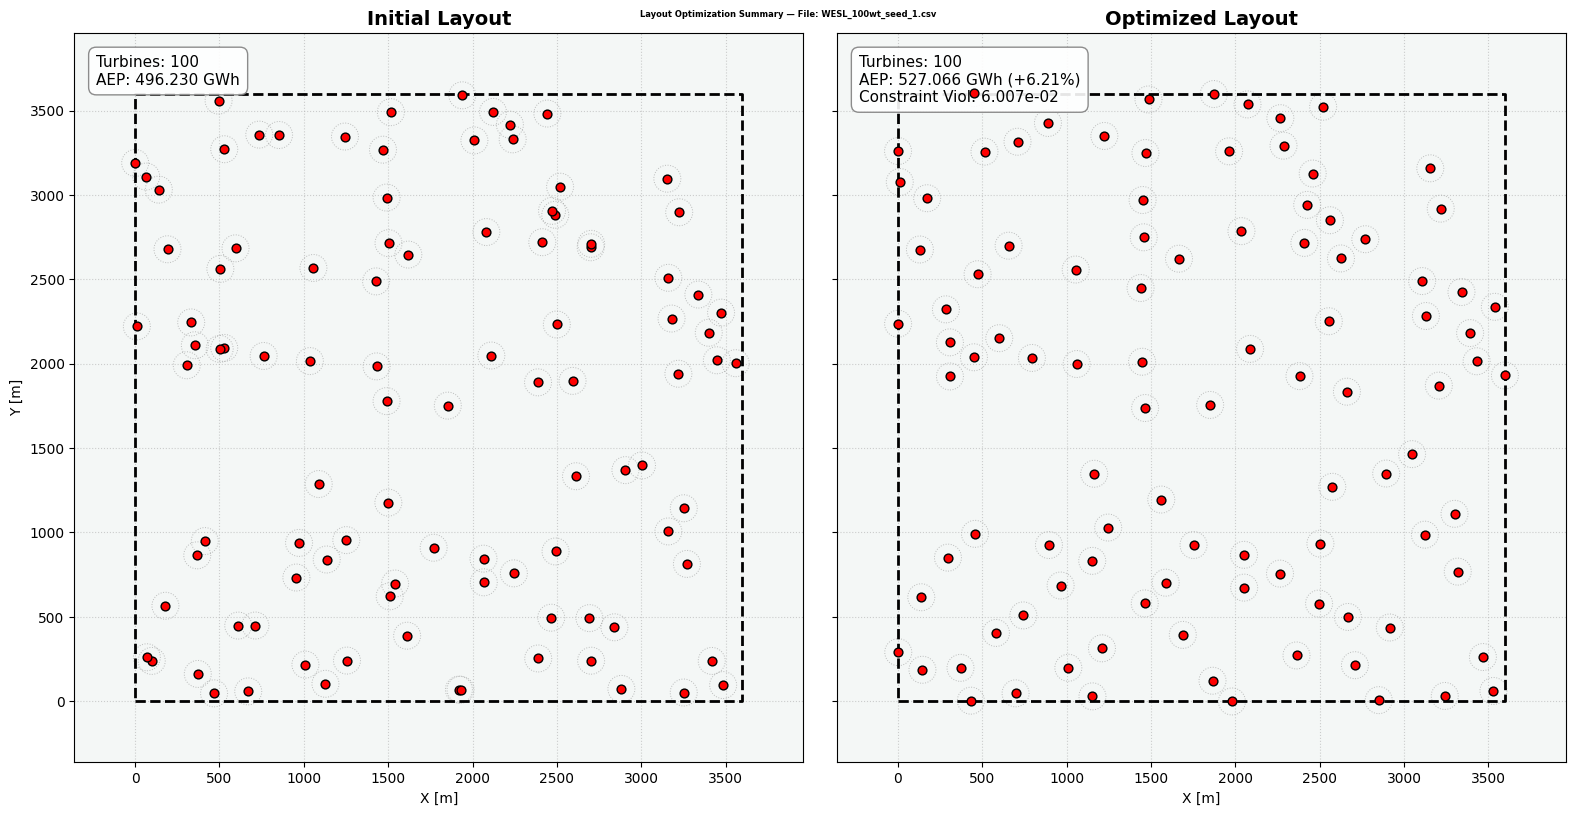

In [9]:
%matplotlib inline
import matplotlib.pyplot as plt


plt.close('all')

# Re-run your plotting setup
params = get_setup_params(csv_filename="100turb_3600m_kdt_1.csv")
D = params['diameter']
min_spacing_m = params['min_spacing_d'] * D

viz = LayoutVisualizer(
    boundary_vertices=params['boundary_vertices'], 
    diameter=D, 
    spacing_meters=min_spacing_m / 2.0
)

viz.load_and_plot(log_path)